In [1]:
import torch
import torch.nn as nn
import os
from transformers import AutoModel, AutoTokenizer
from transformers import BertModel, BertTokenizer
import random
from scipy.interpolate import interp1d
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score,roc_curve
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import torch
import csv
import pandas as pd
import pickle


c:\anaconda\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Model settings
batch_size = 32  # Setting batchsize
learning_rates=0.000065 # Setting learning rates
model_name="esm2_6"#Select different versions of the ESM2 model: esm2_6,esm_12,esm_30.

In [3]:
#Dataset definitions

class MyDataset(Dataset):
    def __init__(self, file):
        self.sequence, self.label = self.read_file(file)
        self.sequence_protbert=self.add_space_between_characters(self.sequence)

    def read_file(self,file_path):
        sequences = []
        labels = []
        with open(file_path, 'r', newline='') as csv_file:
            csv_reader = csv.reader(csv_file)
            next(csv_reader, None)  
            data = list(csv_reader)
            random.seed(42)
            random.shuffle(data)  
            for row in data:
                sequences.append(row[1])
                labels.append(row[2])
        return sequences, labels
    
    def add_space_between_characters(self,input_list):
        new_list = []
        for element in input_list:
            new_element = ' '.join(element)
            new_list.append(new_element)
        return new_list

    def __len__(self):
        return len(self.sequence)

    def __getitem__(self, index):
        sample=self.sequence[index]
        sample_protbert=self.sequence_protbert[index]
        label=int(self.label[index])
        return sample, label, sample_protbert

In [4]:
# Read the training set

train_file = 'E:\\LLM+XWT\\XWT数据\\Umami-BERT-UMP789\\1_1-data.csv'  
train_dataset = MyDataset(train_file)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [5]:
#Define the esm family of models

class MyModel(nn.Module):
    def __init__(self,):
        super(MyModel, self).__init__()
        if model_name=="esm2_30":
            self.model = AutoModel.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D")
            self.layer=640
        elif model_name=="esm2_12":
            self.model = AutoModel.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t12_35M_UR50D")
            self.layer=480
        elif model_name=="esm2_6":
            self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
            self.layer=320
        self.fc2 = nn.Linear(self.layer, 2) 

    def forward(self, inputs,inputs2):
        inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        input_ids = inputs["input_ids"].to(device)
        attention_mask = inputs["attention_mask"].to(device)
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output1 = outputs.pooler_output   
        x=self.fc2(pooler_output1)
        return x

In [6]:
#Model loading and setting

device = torch.device("cpu") 
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model = MyModel()
model.to(device)#Model loading
criterion = nn.CrossEntropyLoss()
loss_all=99999
best_auc=0
all_fpr = []
all_tpr = []
all_aucs = []

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# Five-fold cross-validation

kf = KFold(n_splits=5, shuffle=False)
for fold, (train_indices, valid_indices) in enumerate(kf.split(train_dataset)):
    best_auc=0
    best_acc=0
    train_sampler = SubsetRandomSampler(train_indices)
    valid_sampler = SubsetRandomSampler(valid_indices)
    best_fpr=np.array([])
    best_tpr=np.array([])
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler)
    valid_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=valid_sampler)
    model = MyModel()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000065)
    item=0
    for epoch in range(50):
        item=item+1
        print(item)
        for batch_data, batch_labels, batch_data_protbert in train_dataloader:
            model.train()
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            loss = criterion(outputs, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        all_labels = []
        all_scores = []
        model.eval()      
        for batch_data, batch_labels, batch_data_protbert in valid_dataloader:
            batch_labels = batch_labels.to(device)
            outputs = model(batch_data,batch_data_protbert)
            probabilities = nn.functional.softmax(outputs, dim=1)
            scores = probabilities[:, 1]  

            all_labels.extend(batch_labels.tolist())
            all_scores.extend(scores.tolist())
        fpr, tpr, _ = roc_curve(all_labels, all_scores)
        auc = roc_auc_score(all_labels, all_scores)
        correct_predictions = (np.array(all_scores) >= 0.5).astype(int)
        print(auc)
        if auc>best_auc:
            best_fpr=fpr
            best_tpr=tpr
            best_auc=auc
    all_fpr.append(best_fpr)
    all_tpr.append(best_tpr)
    all_aucs.append(best_auc)
    print(f"Fold {fold + 1}: AUC = {best_auc:.6f}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.929402432575357
2
0.9500264410364886
3
0.9558434690639872
4
0.9500264410364886
5
0.9471179270227393
6
0.9714436805922791
7
0.9640401903754627
8
0.9640401903754627
9
0.9624537281861449
10
0.9569011105235325
11
0.9616604970914859
12
0.9687995769434161
13
0.9635113696456902
14
0.965097831835008
15
0.9661554732945531
16
0.9666842940243257
17
0.9674775251189845
18
0.9677419354838709
19
0.967741935483871
20
0.9682707562136436
21
0.9682707562136436
22
0.9682707562136436
23
0.9685351665785298
24
0.9690639873083025
25
0.9693283976731888
26
0.9701216287678477
27
0.9698572184029614
28
0.9698572184029614
29
0.9698572184029614
30
0.9701216287678477
31
0.9701216287678477
32
0.9698572184029614
33
0.9698572184029614
34
0.9701216287678477
35
0.9701216287678477
36
0.9698572184029614
37
0.9698572184029615
38
0.9698572184029614
39
0.9695928080380751
40
0.9693283976731888
41
0.9693283976731888
42
0.9695928080380751
43
0.9695928080380751
44
0.9695928080380751
45
0.9695928080380751
46
0.9695928080380751


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9271716101694916
2
0.9472987288135593
3
0.9454449152542374
4
0.9653072033898304
5
0.9703389830508474
6
0.9674258474576272
7
0.9690148305084746
8
0.9650423728813559
9
0.9642478813559322
10
0.9610699152542374
11
0.9653072033898304
12
0.9708686440677966
13
0.9655720338983051
14
0.9682203389830509
15
0.9772245762711864
16
0.9679555084745762
17
0.975635593220339
18
0.9668961864406779
19
0.9647775423728814
20
0.9645127118644068
21
0.9642478813559322
22
0.9647775423728813
23
0.9647775423728814
24
0.9647775423728814
25
0.9645127118644068
26
0.9653072033898306
27
0.9653072033898304
28
0.965042372881356
29
0.965042372881356
30
0.9653072033898304
31
0.9655720338983051
32
0.9655720338983051
33
0.9655720338983051
34
0.9658368644067796
35
0.9658368644067796
36
0.9658368644067796
37
0.9661016949152542
38
0.9661016949152542
39
0.9661016949152542
40
0.9661016949152542
41
0.9658368644067796
42
0.9658368644067796
43
0.9658368644067796
44
0.9658368644067796
45
0.9661016949152542
46
0.9663665254237288


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.9371002132196162
2
0.9323027718550106
3
0.9514925373134329
4
0.9509594882729211
5
0.9602878464818763
6
0.9570895522388059
7
0.949360341151386
8
0.9416311300639659
9
0.9530916844349681
10
0.9552238805970149
11
0.9442963752665244
12
0.9482942430703625
13
0.9485607675906182
14
0.9485607675906184
15
0.94909381663113
16
0.9496268656716418
17
0.9498933901918976
18
0.9493603411513859
19
0.94909381663113
20
0.9493603411513859
21
0.94909381663113
22
0.9488272921108741
23
0.9488272921108741
24
0.9485607675906184
25
0.9488272921108741
26
0.9488272921108741
27
0.9488272921108741
28
0.9488272921108741
29
0.9488272921108741
30
0.9485607675906182
31
0.9485607675906182
32
0.9485607675906182
33
0.9485607675906182
34
0.9482942430703625
35
0.9477611940298507
36
0.9477611940298507
37
0.9472281449893389
38
0.9472281449893389
39
0.9472281449893389
40
0.9474946695095948
41
0.9474946695095948
42
0.9474946695095948
43
0.9474946695095948
44
0.9474946695095948
45
0.9474946695095948
46
0.9474946695095948
47
0

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.973030142781597
2
0.9672131147540983
3
0.9743521946060285
4
0.9698572184029614
5
0.9732945531464834
6
0.9685351665785299
7
0.973030142781597
8
0.9690639873083025
9
0.9687995769434162
10
0.9637757800105763
11
0.9687995769434161
12
0.9706504494976204
13
0.9666842940243258
14
0.9695928080380751
15
0.9690639873083025
16
0.9685351665785298
17
0.9680063458487572
18
0.9677419354838709
19
0.9672131147540983
20
0.9669487043892121
21
0.9666842940243258
22
0.9666842940243258
23
0.9664198836594394
24
0.966155473294553
25
0.9656266525647805
26
0.9658910629296666
27
0.9658910629296666
28
0.9658910629296668
29
0.9658910629296668
30
0.9653622421998943
31
0.9653622421998942
32
0.9653622421998943
33
0.9653622421998942
34
0.9653622421998943
35
0.9650978318350079
36
0.9648334214701215
37
0.9648334214701216
38
0.9645690111052353
39
0.9640401903754626
40
0.9640401903754626
41
0.9637757800105763
42
0.9637757800105763
43
0.9637757800105763
44
0.9640401903754626
45
0.9640401903754626
46
0.9640401903754626


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


1
0.8596491228070176
2
0.8979757085020242
3
0.9336032388663967
4
0.9295546558704454
5
0.9425101214574899
6
0.9365721997300945
7
0.9365721997300944
8
0.9446693657219974
9
0.9530364372469636
10
0.9422402159244265
11
0.9433198380566802
12
0.9484480431848853
13
0.9438596491228071
14
0.9398110661268556
15
0.936302294197031
16
0.9174089068825911
17
0.9390013495276653
18
0.9284750337381916
19
0.9322537112010797
20
0.9327935222672065
21
0.9336032388663967
22
0.9338731443994602
23
0.9336032388663968
24
0.9336032388663968
25
0.9338731443994603
26
0.9338731443994603
27
0.9346828609986505
28
0.9346828609986505
29
0.9341430499325236
30
0.9341430499325236
31
0.9346828609986505
32
0.9341430499325236
33
0.934412955465587
34
0.9341430499325237
35
0.9341430499325237
36
0.9341430499325237
37
0.9338731443994602
38
0.9341430499325236
39
0.9341430499325236
40
0.9341430499325236
41
0.9341430499325236
42
0.9338731443994601
43
0.9338731443994602
44
0.9338731443994601
45
0.9338731443994602
46
0.9338731443994601

In [8]:
# 步骤 1: 解耦保存数据 (Decoupling: Save Data)
# ---------------------------------------------------------
save_dir = 'E:/LLM+XWT/实验结果/Five_fold_esm_2_6_XWT/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

data_save_path = os.path.join(save_dir, '5_fold_data.pkl')
with open(data_save_path, 'wb') as f:
    pickle.dump({'all_fpr': all_fpr, 'all_tpr': all_tpr, 'all_aucs': all_aucs}, f)

print(f"Data saved to {data_save_path}. You can load this next time to skip training.")

Data saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_6_XWT/5_fold_data.pkl. You can load this next time to skip training.


In [9]:
# --- 全局字体与绘图设置 (Arial, Bold, Size 22) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold' # 坐标轴标签加粗
plt.rcParams['font.size'] = 22

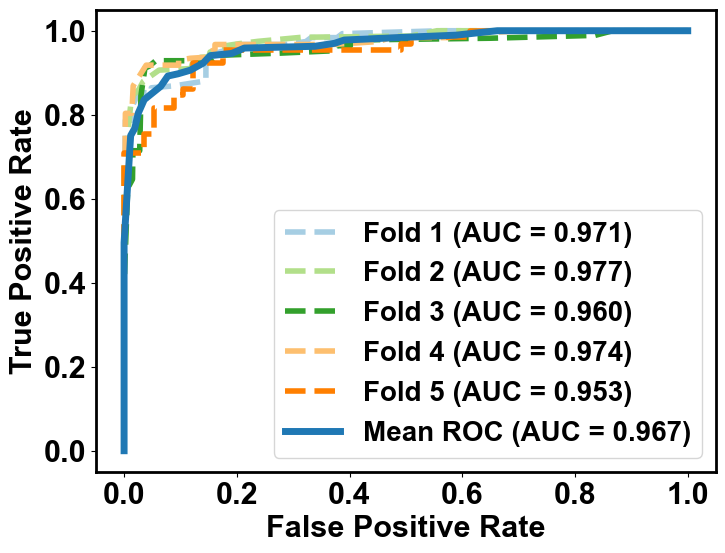

AUC for each fold: [np.float64(0.9714436805922791), np.float64(0.9772245762711864), np.float64(0.9602878464818763), np.float64(0.9743521946060285), np.float64(0.9530364372469636)]
Mean AUC: 0.9672689470396669
Image saved to E:/LLM+XWT/实验结果/Five_fold_esm_2_6_XWT/5_fold_roc_refined.png


In [10]:
#Drawing roc diagrams
# ---------------------------------------------------------
# 步骤 2: 绘图 (Plotting with custom styles)
# ---------------------------------------------------------
# 如果需要单独运行绘图，可以从这里开始，并加载上面的pkl文件
# with open(data_save_path, 'rb') as f:
#     data = pickle.load(f)
#     all_fpr = data['all_fpr']
#     all_tpr = data['all_tpr']
#     all_aucs = data['all_aucs']

# 指定配色
custom_colors = ["#A6CEE3", "#B2DF8A", "#33A02C", "#FDBF6F", "#FF7F00", "#FB9A99", "#1F78B4"]

plt.figure(figsize=(8, 6)) # 稍微调大一点画布以适应大字体

# 插值平滑处理 (保持原逻辑)
max_length = max(len(fpr) for fpr in all_fpr)
new_all_fpr = []
new_all_tpr = []
for fpr, tpr in zip(all_fpr, all_tpr):
    f = interp1d(np.linspace(0, 1, len(fpr)), fpr)
    t = interp1d(np.linspace(0, 1, len(tpr)), tpr)
    new_fpr = f(np.linspace(0, 1, max_length))
    new_tpr = t(np.linspace(0, 1, max_length))
    new_all_fpr.append(new_fpr)
    new_all_tpr.append(new_tpr)
all_fpr = new_all_fpr
all_tpr = new_all_tpr

# 绘制每一折
for i in range(len(all_fpr)):
    color_idx = i % len(custom_colors)
    plt.plot(all_fpr[i], all_tpr[i], 
             linestyle='--', 
             lw=4, # 线条加粗
             color=custom_colors[color_idx],
             label=f'Fold {i + 1} (AUC = {all_aucs[i]:.3f})')

# 绘制平均曲线
mean_fpr = np.mean(all_fpr, axis=0)
mean_tpr = np.mean(all_tpr, axis=0)
mean_color = custom_colors[-1] # 使用最后一个粉色或者您指定的颜色

plt.plot(mean_fpr, mean_tpr, 
         color=mean_color, 
         linestyle='-', 
         lw=5, # 平均线更粗一点
         label='Mean ROC (AUC = {:.3f})'.format(np.mean(all_aucs)))

# 设置图形属性
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate', fontsize=22, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=22, fontweight='bold')

# 刻度字体设置
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=22, fontweight='bold')

# 图例设置 (Arial, Bold, 20 - 稍微小一点以免遮挡，或者也用22)
# 注意：matplotlib图例自动继承全局字体，但为了保险起见可以强制指定
plt.legend(loc="lower right", fontsize=20, prop={'family': 'Arial', 'weight': 'bold', 'size': 20})

# 加粗边框 (可选，为了学术风更强)
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# 保存图片
image_save_path = os.path.join(save_dir, '5_fold_roc_refined.png')
plt.savefig(image_save_path, dpi=600, bbox_inches='tight')
plt.show()

print("AUC for each fold:", all_aucs)
print("Mean AUC:", np.mean(all_aucs))
print(f"Image saved to {image_save_path}")